# Loading required libraries

In [1]:
library(ggplot2)
library(patchwork)
library(scales)
library(tidyverse)
library(ggpubr)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(showtext)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reve

## Figures and Files Setup

In [5]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_4"

# Color palettes

In [30]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


cluster_palette <- c(

  "Tumor_bulk" = "#00B3A4",

  "Lymphoid_T" = "#D62828",

  "Myeloid_granulocytic" = "#6A00F4",

  "Tumor_myeloid" = "#80ED99",

  "Lymphoid_B" = "#FFB703",

  "Lymphatic_immune" = "#1F78B4",

  "Vascular/Endothelial" = "#00BFC4",

  "Stromal_fibroblasts" = "#B39DDB",

  "Stromal_NFC" = "#6C757D",

  "Epithelial_adjacent" = "#C9B29B",

  "Tumor_NFC" = "#CED4DA",

  "Lymphoid_enriched" = "#E76F51"
)
gvsm2_colors = c(
    "Granulocyte-dominant" = "#B85AA6",
    "M2 Macrophage-dominant" = "#66A61E"
)

# Load the required data

In [7]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
#niches df 
niches_df <- read.csv(file.path(data_dir, "niches_df.csv"))

In [6]:
#niches enrichment and pvalues
enr_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment.csv"))
pvalue_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"))

Rows: 19 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (12): Epithelial_adjacent, Lymphatic_immune, Lymphoid_B, Lymphoid_T, Lym...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 19 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (12): Epithelial_adjacent, Lymphatic_immune, Lymphoid_B, Lymphoid_T, Lym...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# B

In [7]:
cluster_composition <- niches_df %>%
    group_by(neighborhood, cell_category) %>%
    summarise(n_cells = n()) %>%
    ungroup() %>%
    group_by(neighborhood) %>%
    mutate("total_n" = sum(n_cells)) %>%
    ungroup() %>%
    mutate("percentage" = (n_cells / total_n) * 100) %>%
    select(!total_n)
cluster_composition

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by neighborhood and cell_category.
ℹ Output is grouped by neighborhood.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(neighborhood, cell_category))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


neighborhood,cell_category,n_cells,percentage
<chr>,<chr>,<int>,<dbl>
Epithelial_adjacent,Actin+ cells,46,0.43220896
Epithelial_adjacent,B cells,10,0.09395847
Epithelial_adjacent,CD4+ T cells,56,0.52616743
Epithelial_adjacent,CD8+ T cells,178,1.67246077
Epithelial_adjacent,DCs,25,0.23489618
Epithelial_adjacent,Endothelial cells,88,0.82683454
Epithelial_adjacent,Epithelial cells,8163,76.69829935
Epithelial_adjacent,Granulocytes,334,3.13821291
Epithelial_adjacent,Lymphatic endothelial cells,148,1.39058536


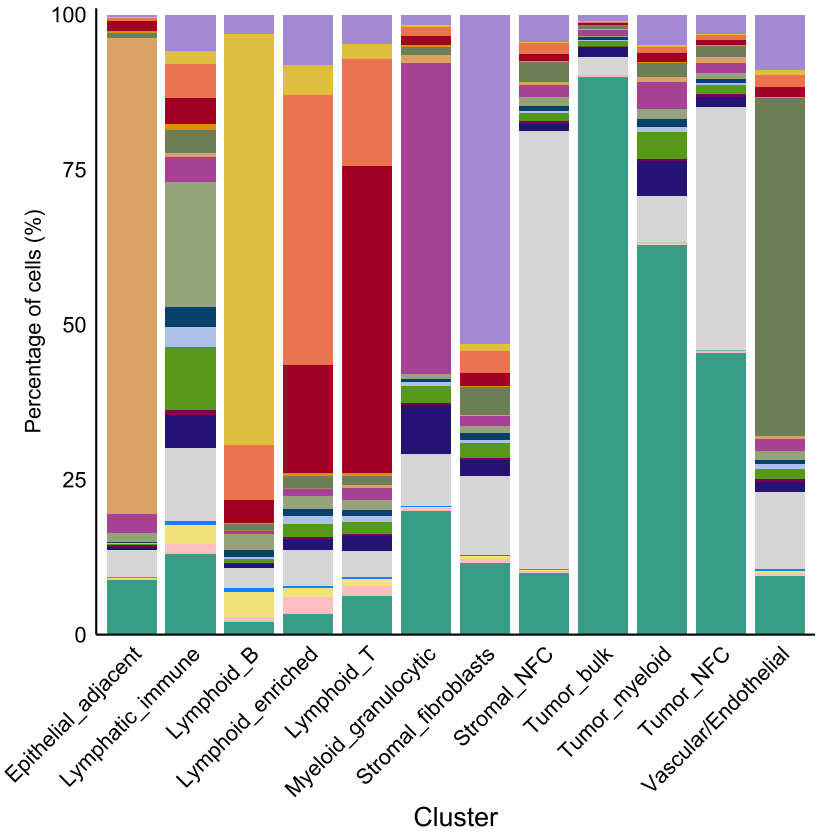

In [55]:
shared_margin <- margin(t = 5, r = 15, b = 5, l = 15)

p_cluster <- ggplot(
  cluster_composition,
  aes(x = neighborhood, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cluster",
    y = "Percentage of cells (%)",
    fill = "Cell type"
  ) +
  scale_y_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),

    # restore y-axis text + title
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13),

    # rotate x labels
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank(),
    plot.margin = shared_margin
  )

p_cluster

showtext_opts(dpi = 300)
ggsave(
  filename = file.path(results_dir, "cluster_composition_barplot.png"),
  plot = p_cluster,
  width = 7,
  height = 6,
  dpi = 300,
  bg = "white"
)

# C

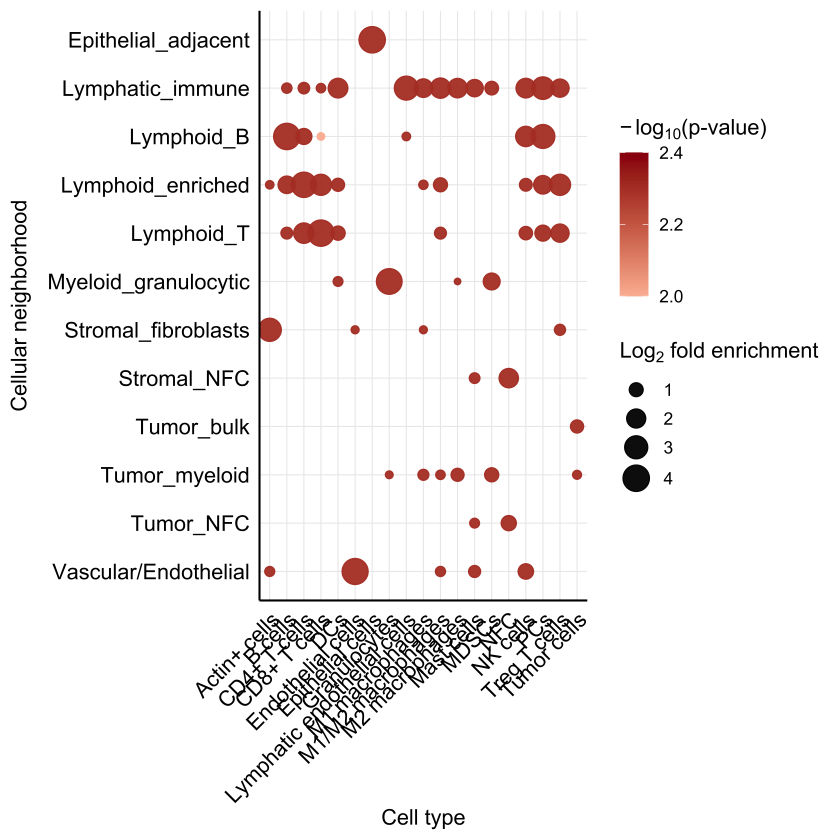

In [8]:
p_long <- pvalue_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "pvalue"
  )

enr_long <- enr_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "enrichment"
  )

df_plot <- enr_long %>%
  left_join(p_long, by = c("cell_category", "neighborhood")) %>%
  mutate(
    neighborhood = factor(neighborhood, levels = sort(unique(neighborhood))),
    cell_category = factor(cell_category)
  )

df_plot_filt <- df_plot %>%
  filter(enrichment > 0, pvalue < 0.01) %>%
  mutate(
    enrichment_cap = pmin(enrichment, 4),
    neglog10_p = -log10(pvalue)
  )

p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) + 
  scale_size_area(
    max_size = 7,
    breaks = c(1, 2, 3, 4),
    name = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
  low = "#fcbba1",
  high = "#99000d",
  name = expression(-log[10] * "(p-value)"),
  limits = c(2, 2.4),
  breaks = c(2.0, 2.2, 2.4)
) +
  labs(
    x = "Cell type",
    y = "Cellular neighborhood"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial", colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 13, colour = "black"),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line = element_line(color = "black")
  )
p
ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot = p,
  width = 10,
  height = 6,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

In [9]:
# ── Niche color strip ─────────────────────────────────────────────────────────
niche_strip <- ggplot(
  data.frame(neighborhood = levels(df_plot_filt$neighborhood)),
  aes(x = 1, y = neighborhood, fill = neighborhood)
) +
  geom_tile() +
  scale_fill_manual(values = cluster_palette) +
  scale_y_discrete(limits = rev) +
  theme_void() +
  theme(legend.position = "none")

# ── Main dot plot ─────────────────────────────────────────────────────────────
p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_area(
    max_size = 7,
    breaks   = c(1, 2, 3, 4),
    name     = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
    low    = "#fcbba1",
    high   = "#99000d",
    name   = expression(-log[10] * "(p-value)"),
    limits = c(2, 2.4),
    breaks = c(2.0, 2.2, 2.4)
  ) +
  labs(
    x = "Cell type",
    y = "Cellular neighborhood"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text             = element_text(family = "Arial", colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x      = element_text(angle = 45, hjust = 1, vjust = 1,
                                    size = 13, colour = "black"),
    axis.text.y      = element_text(size = 13, colour = "black"),
    axis.title.y     = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.title.x     = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line        = element_line(color = "black")
  )

# ── Combine: strip on the left, dot plot on the right ────────────────────────
combined <- niche_strip + p +
  plot_layout(widths = c(0.03, 1))

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot     = combined,
  width    = 11,
  height   = 6,
  device   = "pdf",
  dpi      = 300,
  bg       = "white"
)

In [22]:
# ── Niche color strip ─────────────────────────────────────────────────────────
niche_strip <- ggplot(
  data.frame(neighborhood = factor(levels(df_plot_filt$neighborhood),
                                   levels = levels(df_plot_filt$neighborhood))),
  aes(x = 1, y = neighborhood, fill = neighborhood)
) +
  geom_tile() +
  scale_fill_manual(values = cluster_palette) +
  scale_y_discrete(limits = rev) +
  labs(y = "Cellular neighborhood") +
  theme_void() +
  theme(
    legend.position = "none",
    axis.text.y     = element_text(size = 13, colour = "black", hjust = 0),
    axis.title.y    = element_text(size = 13, colour = "black", angle = 90, margin = margin(r = 10))
  )

# ── Main dot plot ─────────────────────────────────────────────────────────────
p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_area(
    max_size = 7,
    breaks   = c(1, 2, 3, 4),
    name     = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
    low    = "#fcbba1",
    high   = "#99000d",
    name   = expression(-log[10] * "(p-value)"),
    limits = c(2, 2.4),
    breaks = c(2.0, 2.2, 2.4)
  ) +
  labs(
    x = "Cell type",
    y = NULL
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text             = element_text(family = "Arial", colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x      = element_text(angle = 45, hjust = 1, vjust = 1,
                                    size = 13, colour = "black"),
    axis.text.y      = element_blank(),
    axis.title.y     = element_blank(),
    axis.ticks.y     = element_blank(),
    axis.title.x     = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line        = element_line(color = "black")
  )

# ── Combine: strip on the left with names, dot plot on the right ──────────────
combined <- niche_strip + p +
  plot_layout(widths = c(0.05, 1))

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot     = combined,
  width    = 11,
  height   = 6,
  device   = "pdf",
  dpi      = 300,
  bg       = "white"
)

# D

In [57]:
#percentage of clusters per patient
patient_clusters <- niches_df %>%
  group_by(patient_ID, neighborhood) %>%
  summarise(n_cells = n()) %>%
  ungroup() %>%
  group_by(patient_ID) %>%
  mutate(percentage = (n_cells / sum(n_cells)) * 100) %>%
  ungroup() %>%
  mutate("patient_ID" = factor(patient_ID, levels = patient_ID_order)) %>%
  arrange(patient_ID)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by patient_ID and neighborhood.
ℹ Output is grouped by patient_ID.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(patient_ID, neighborhood))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


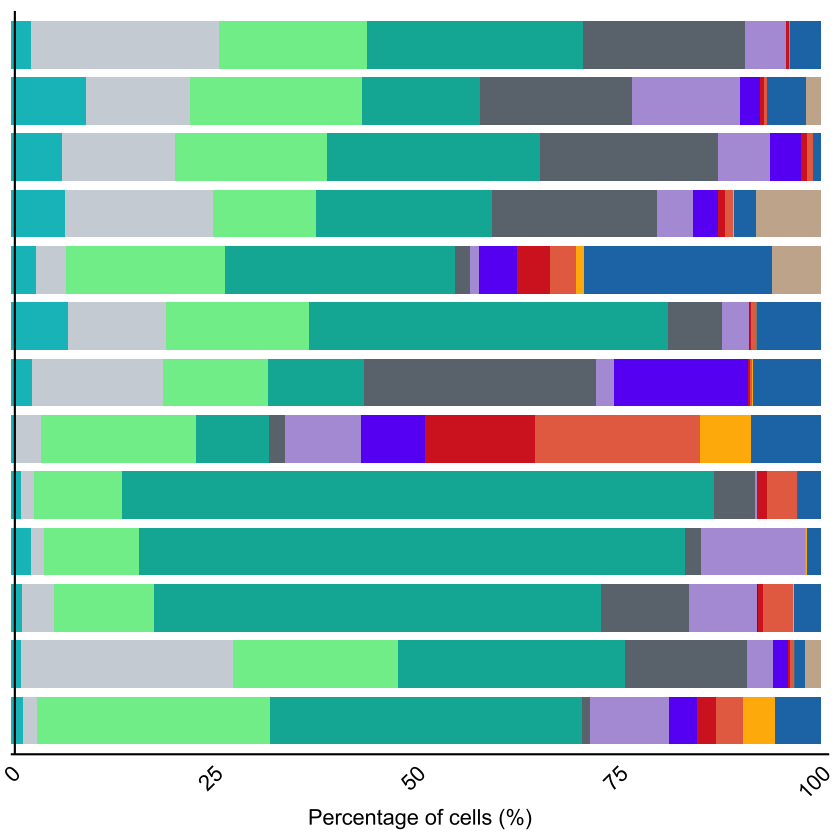

In [63]:
p_patient <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()
  )
p_patient

In [64]:
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "right",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend.pdf"),
  plot = p_patient_legend_only,
  width = 3,
  height = 4.5,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

#one on the bottom 
#save the legend 

p_patient_legend <- ggplot(
  patient_clusters,
  aes(x = percentage, y = patient_ID, fill = neighborhood)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = cluster_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "Cluster"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y  = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()  
    )
p_patient_legend_only <- get_legend(p_patient_legend)
ggsave(
  filename = file.path(results_dir, "patient_cluster_legend_bottom.pdf"),
  plot = p_patient_legend_only,
  width = 10,
  height = 1,
  device = "pdf",
  dpi = 300,
  bg = "white"
)

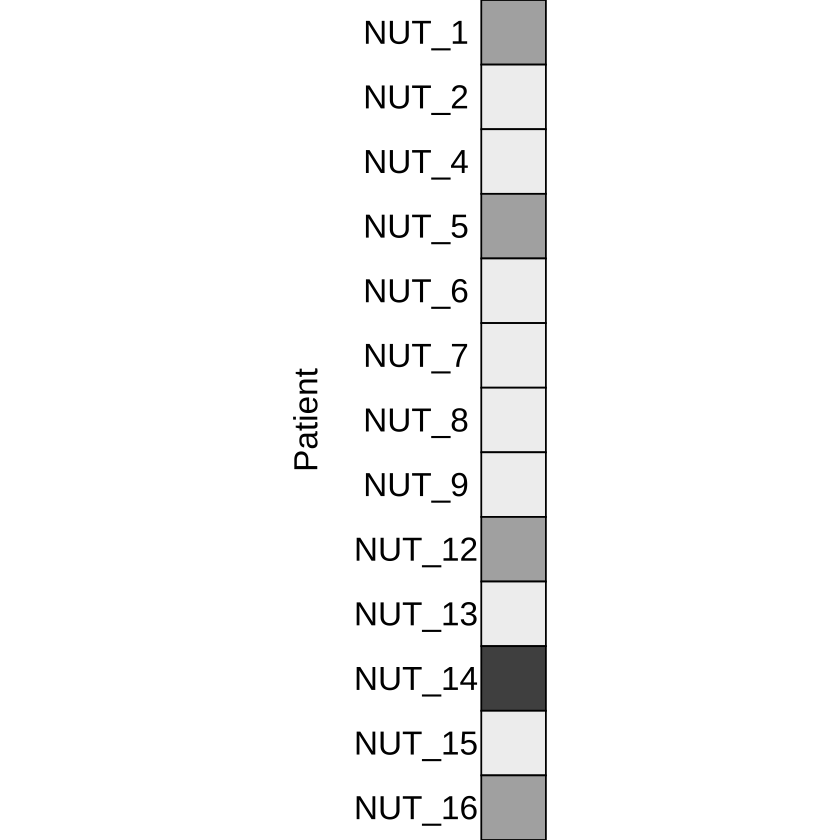

In [65]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

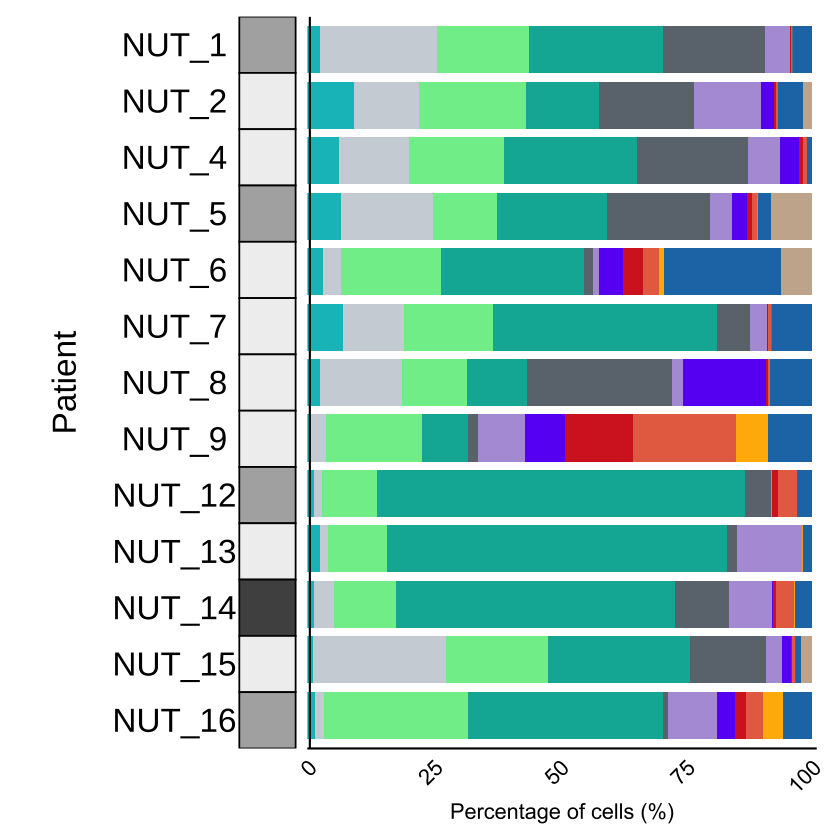

In [66]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_patient,
  ncol = 3,
  widths = c(1,-0.5,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = file.path(results_dir, "clusters_per_patient_tissue.pdf"),
  plot = final_plot,
  width = 8,
  height = 6,
  dpi = 300
)


# E

In [31]:
plot_niches <- function(df, title = NULL,
                        color_var = "neighborhood",
                        palette = cluster_palette,
                        bg_color = "#D9D9D9", bg_alpha = 1, pt_size_fg = 1.5) {

  ggplot() +
    geom_point(
      data = df,
      aes(x = `Cell.Center.X`, y = `Cell.Center.Y`, color = .data[[color_var]]),
      alpha = 0.95,
      size  = pt_size_fg
    ) +
    scale_color_manual(
      values = palette,
      drop   = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title  = element_blank(),
      plot.title    = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}

In [24]:
plot_niches <- function(df, title = NULL,
                        color_var = "neighborhood",
                        palette = cluster_palette,
                        highlight = NULL,       # vector of neighborhoods/celltypes to highlight
                        bg_color = "#D9D9D9", bg_alpha = 1, pt_size_fg = 1.5) {

  if (!is.null(highlight)) {
    df_fg <- df %>% filter(.data[[color_var]] %in% highlight)
    df_bg <- df %>% filter(!.data[[color_var]] %in% highlight)
  } else {
    df_fg <- df
    df_bg <- NULL
  }

  p <- ggplot()

  # grey background points if highlight is used
  if (!is.null(df_bg) && nrow(df_bg) > 0) {
    p <- p + geom_point(
      data  = df_bg,
      aes(x = `Cell.Center.X`, y = `Cell.Center.Y`),
      color = bg_color,
      alpha = bg_alpha,
      size  = pt_size_fg
    )
  }

  # foreground colored points
  p <- p + geom_point(
    data = df_fg,
    aes(x = `Cell.Center.X`, y = `Cell.Center.Y`, color = .data[[color_var]]),
    alpha = 0.95,
    size  = pt_size_fg
  ) +
  scale_color_manual(
    values = palette,
    drop   = TRUE
  ) +
  coord_equal() +
  theme_void() +
  theme(
    legend.title    = element_blank(),
    plot.title      = element_text(hjust = 0.5),
    legend.position = "none"
  ) +
  ggtitle(title) +
  scale_y_reverse()

  p
}

# F

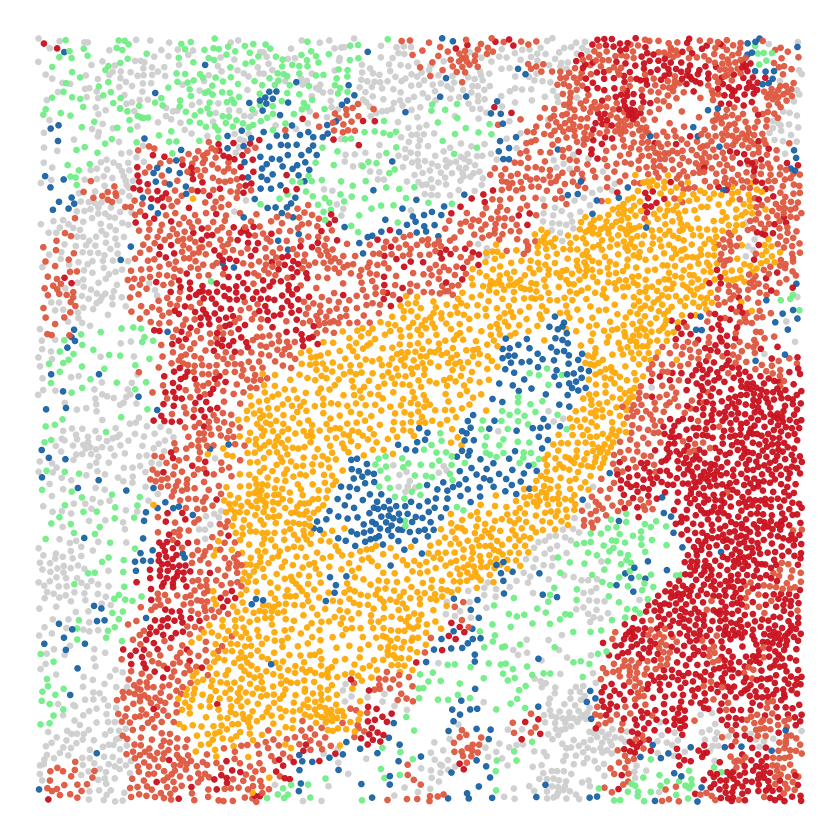

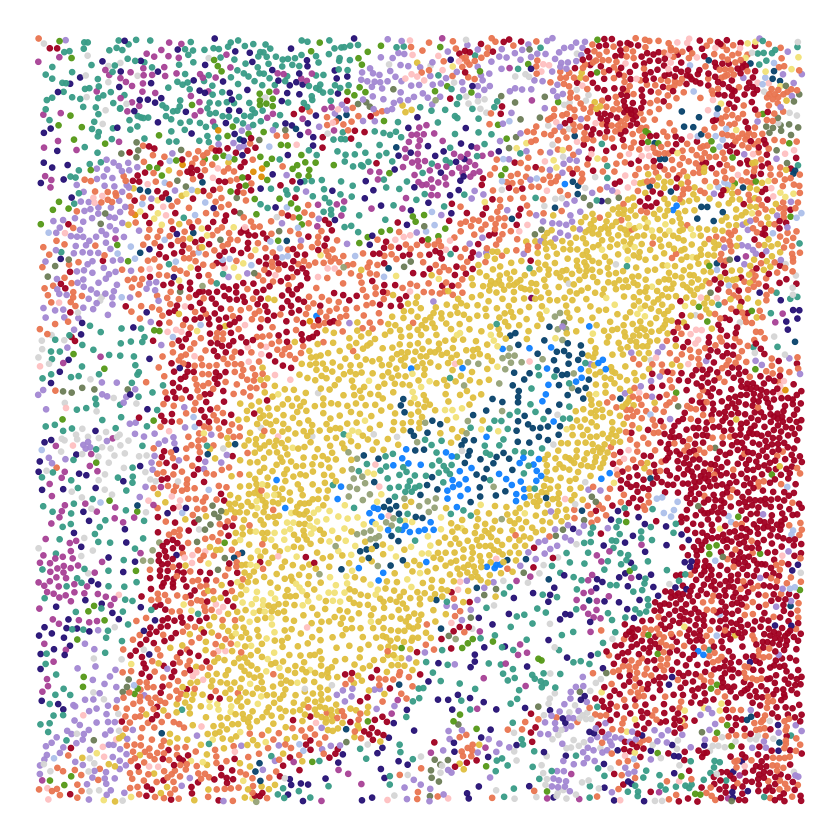

In [29]:
exp <- "NUT_9_ROI4"
df <- niches_df %>%
    filter(Cell.Center.X > 6200 & Cell.Center.X < 11200 & Cell.Center.Y > 2700 & Cell.Center.Y < 7700) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Lymphoid_B", "Lymphoid_T", "Lymphoid_enriched", "Lymphatic_immune", "Tumor_myeloid"))
  p



ggsave(filename = paste0(results_dir, "/NUT_9_ROI4_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")

p <- plot_niches(color_var = "cell_category", palette = full_palette,
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_9_ROI4_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



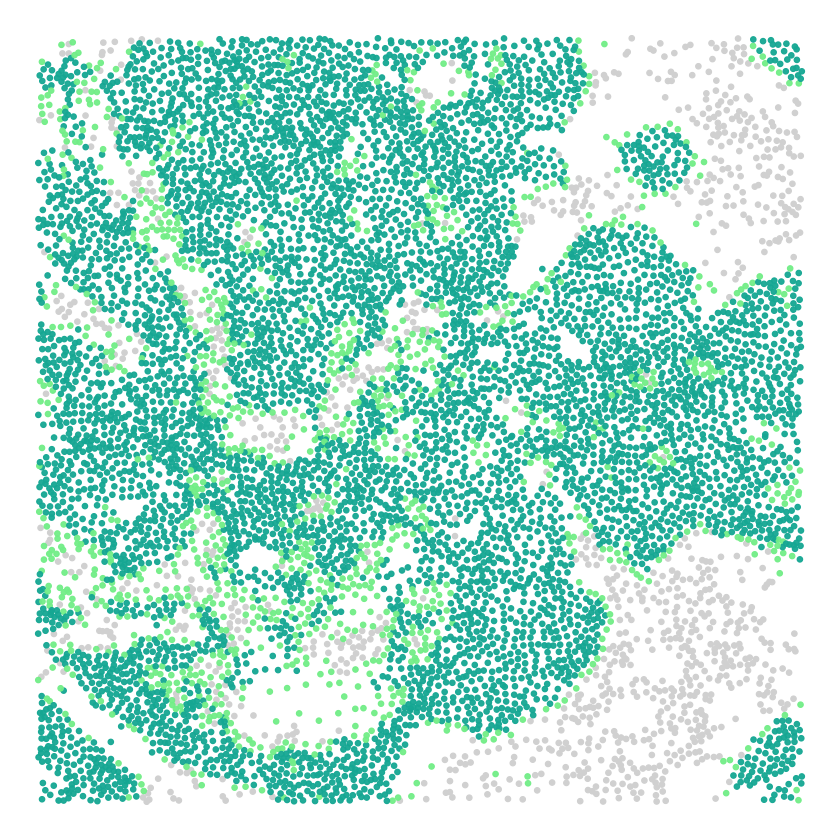

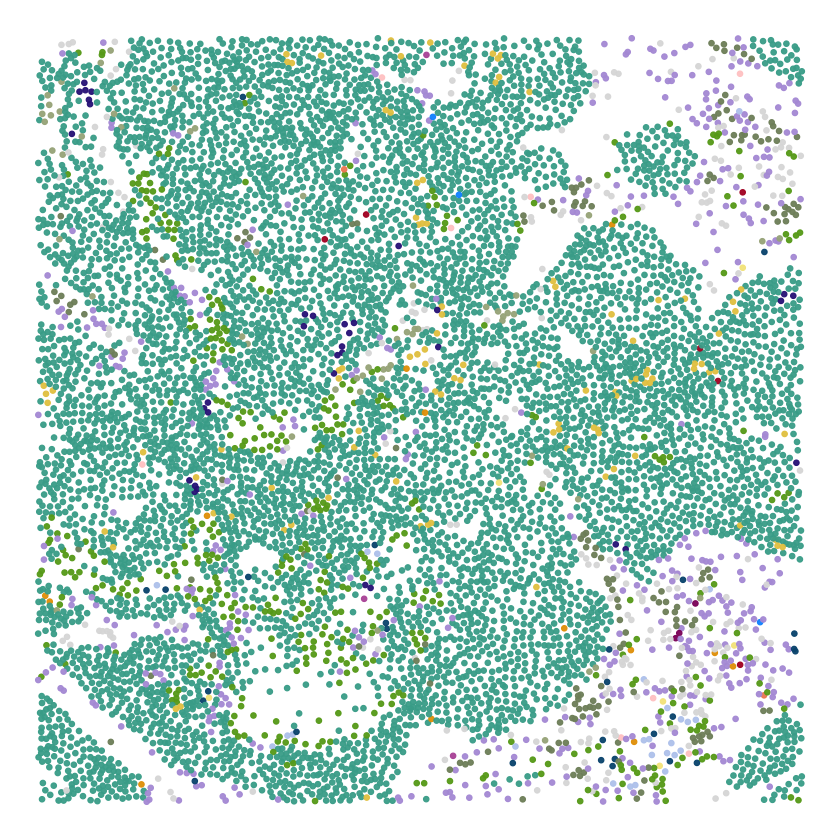

In [32]:
exp <- "NUT_13_ROI15"
df <- niches_df %>%
    filter(Cell.Center.X > 3000 & Cell.Center.X < 8000 & Cell.Center.Y > 2000 & Cell.Center.Y < 7000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Tumor_bulk", "Tumor_myeloid"))
  p



ggsave(filename = paste0(results_dir, "/NUT_13_ROI15_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")

p <- plot_niches(color_var = "cell_category", palette = full_palette,
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_13_ROI15_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



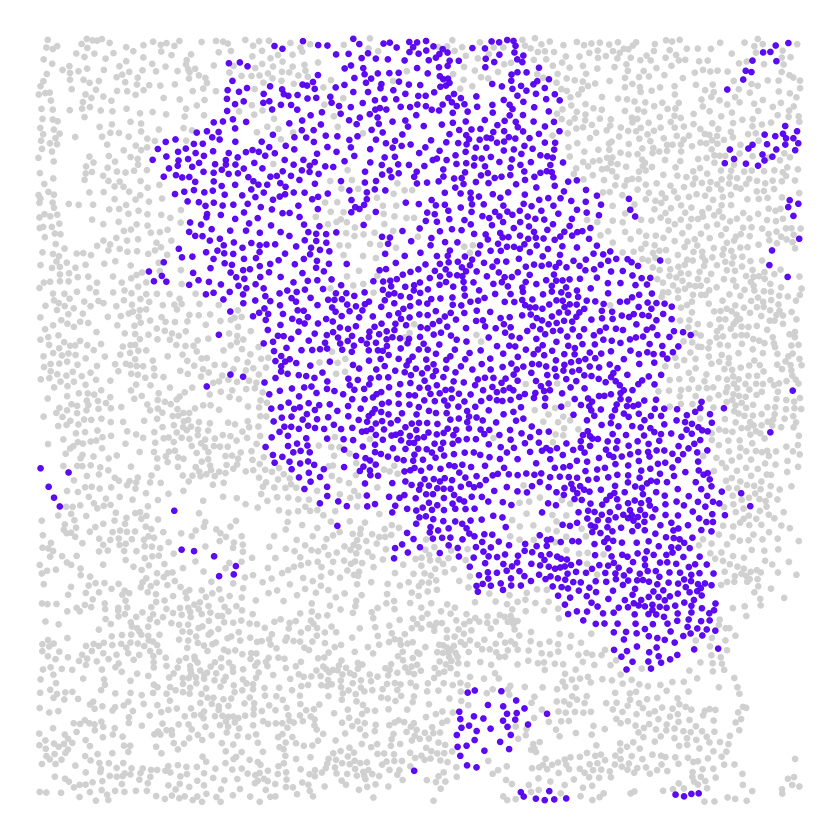

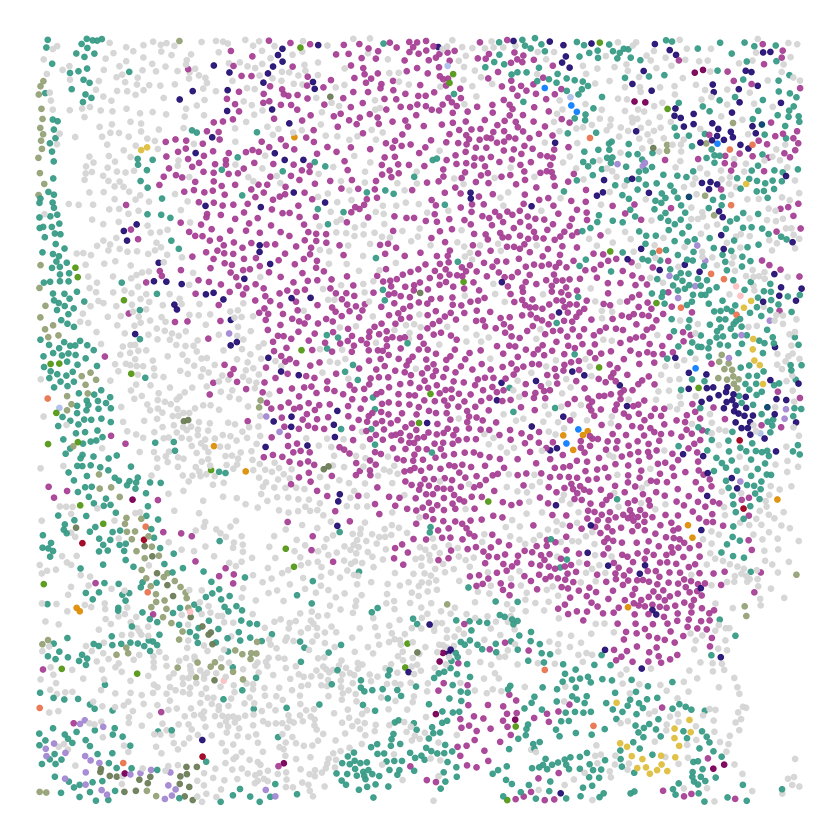

In [39]:
exp <- "NUT_8_ROI17"
df <- niches_df %>%
    filter(Cell.Center.X > 4500 & Cell.Center.X < 9500 & Cell.Center.Y > 1000 & Cell.Center.Y < 6000) %>%
    filter(patient_exp == exp)


p <- plot_niches(
  df, pt_size_fg = 1.2,
  highlight = c("Myeloid_granulocytic"))
  p



ggsave(filename = paste0(results_dir, "/NUT_8_ROI17_selected_niches.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")

p <- plot_niches(color_var = "cell_category", palette = full_palette,
  df, pt_size_fg = 1.2)
  p




ggsave(filename = paste0(results_dir, "/NUT_8_ROI17_selected_cells.png"),
       plot = p,
       width = 5,
       height = 5,
       dpi = 300,
       bg = "white")



In [9]:
niches_df

patient_ID,patient_exp,cell_category,Cell.Center.X,Cell.Center.Y,survival_time_months,neighborhood
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NUT_1,NUT_1_ROI1,NFC,2480.7239,4857.791,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,3722.4333,2900.642,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,12466.3662,2890.018,170,Tumor_myeloid
NUT_1,NUT_1_ROI3,Tumor cells,2737.7788,2875.279,170,Tumor_bulk
NUT_1,NUT_1_ROI3,Tumor cells,2318.3650,2911.225,170,Tumor_myeloid
NUT_1,NUT_1_ROI3,Tumor cells,603.0942,2886.603,170,Tumor_bulk
NUT_1,NUT_1_ROI3,NFC,11714.1533,2903.130,170,Tumor_NFC
NUT_1,NUT_1_ROI3,NFC,9563.5957,2888.619,170,Tumor_NFC
NUT_1,NUT_1_ROI3,Tumor cells,4836.6763,2890.952,170,Tumor_myeloid


In [18]:
tumor_myeloid_percentage <- niches_df %>%
  filter(neighborhood == "Tumor_myeloid",
  cell_category %in% c("MDSCs", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "Granulocytes")) %>%
  group_by(patient_ID) %>%
  mutate(total_cells = n()) %>%                         
  ungroup() %>%
  group_by(patient_ID, cell_category) %>%
  summarise(
    count      = n(),
    total_cells = first(total_cells),
    percentage  = (count / total_cells) * 100,
    .groups    = "drop"
  )


patient_ID,cell_category,count,total_cells,percentage
<chr>,<chr>,<int>,<int>,<dbl>
NUT_1,Granulocytes,1,553,0.1808318
NUT_1,M1 macrophages,78,553,14.1048825
NUT_1,M1/M2 macrophages,183,553,33.0922242
NUT_1,M2 macrophages,217,553,39.2405063
NUT_1,MDSCs,74,553,13.3815552
NUT_12,Granulocytes,3,363,0.8264463
NUT_12,M1 macrophages,178,363,49.0358127
NUT_12,M1/M2 macrophages,3,363,0.8264463
NUT_12,M2 macrophages,168,363,46.2809917


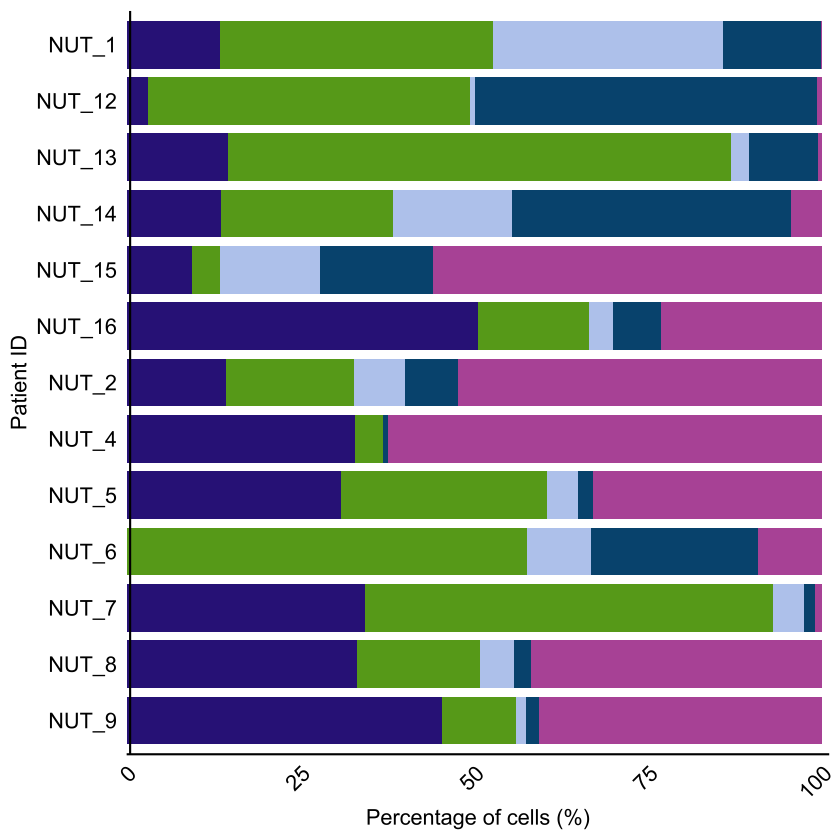

In [25]:
p_patient <- ggplot(
  tumor_myeloid_percentage,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  geom_vline(xintercept = 0.5, colour = "black", linewidth = 0.6) +
  scale_fill_manual(values = full_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of cells (%)",
    y = "Patient ID",
    fill = "cell_category"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0)) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(family = "Arial"),
    axis.text.y  = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black"),
    axis.text.x = element_text(size = 13, angle = 45, hjust = 1, vjust = 1, colour = "black"),
    axis.title  = element_text(size = 13, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),

    axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
    axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),
    axis.line.y.left   = element_blank(),
    axis.line.y.right  = element_blank(),

    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),

    panel.grid = element_blank()
  )
p_patient

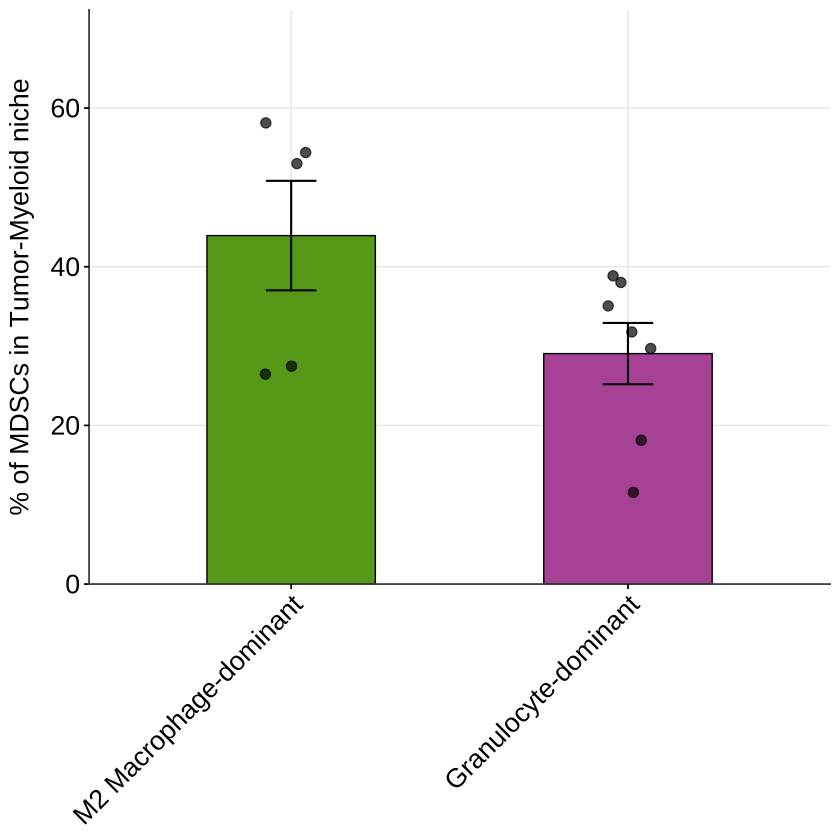

In [33]:
# Summarise to group level (mean ± SE)
niche_mdsc_summary <- niche_mdsc_compare %>%
  group_by(dominant_label) %>%
  summarise(
    mean_pct = mean(percentage, na.rm = TRUE),
    se_pct   = sd(percentage, na.rm = TRUE) / sqrt(n()),
    .groups  = "drop"
  )

# Plot
ggplot(niche_mdsc_summary, aes(x = dominant_label, y = mean_pct, fill = dominant_label)) +

  geom_col(
    width = 0.5,
    color = "black",
    linewidth = 0.4
  ) +

  geom_errorbar(
    aes(ymin = mean_pct - se_pct, ymax = mean_pct + se_pct),
    width     = 0.15,
    linewidth = 0.6,
    color     = "black"
  ) +

  geom_jitter(
    data  = niche_mdsc_compare,
    aes(x = dominant_label, y = percentage),
    width = 0.08,
    size  = 2.5,
    alpha = 0.7,
    color = "black"
  ) +

  scale_fill_manual(values = gvsm2_colors) +

  scale_y_continuous(expand = c(0, 0),
                     limits = c(0, max(niche_mdsc_compare$percentage, na.rm = TRUE) * 1.25)) +

  labs(
    x = NULL,
    y = "% of MDSCs in Tumor-Myeloid niche"
  ) +

  theme_classic(base_size = 12) +
  theme(
    legend.position  = "none",
    axis.text.x      = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/mdsc_niche_gran_vs_m2_barplot.pdf"),
       width = 5, height = 6, dpi = 300, bg = "white")